In [2]:
import numpy as np
import torch
from matplotlib import pyplot as plt
import torcwa
from tqdm.notebook import tqdm
from pvlib import spectrum
from refractiveindex import RefractiveIndexMaterial
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from Utils.utils import get_absorptance

%load_ext line_profiler

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')



def get_sine_eps(x,params,grating_period,eps):
    """Generate sine grating permittivity profile.

    Args:
        x (torch.tensor): 1D tensor of x positions.
        params (torch.Tensor): list of amplitude and phase shift. shape (n,2), where n is n*2*np.pi/grating_period'th frequency.
        eps (float): Permittivity of high-index material.

    Returns:
        torch.tensor: 1D tensor of permittivity profile.
    """
    A = torch.sum(params[:,0]) + 1e-9
    cosines = torch.cos(2.*np.pi*torch.arange(1, params.shape[0]+1, 
                                              dtype=geo_dtype,device=device).unsqueeze(1)*(x.unsqueeze(0)/grating_period)
                                               - params[:,1].unsqueeze(1))
    cosines = cosines * params[:,0].unsqueeze(1)
    eps = 1 + (eps-1)*(0.5*(A+torch.sum(cosines, dim=0))/A)
    return eps.unsqueeze(1)   # make shape (nx,1) so add_layer accepts it

# Simulation environment
# light
inc_ang = 30.*(np.pi/180)    # radian
azi_ang = 30.*(np.pi/180)    # radian
spectra = spectrum.get_reference_spectra()
am15g = spectra['global']
wavelengths = torch.linspace(300,1100,100,dtype=int) # nm
sun_weights = torch.tensor(am15g[wavelengths.cpu().numpy()].to_numpy())

# material
si = RefractiveIndexMaterial(shelf='main', book='Si', page='Green-2008')
si_eps = torch.tensor(si.get_refractive_index(wavelengths.cpu().numpy()) +
                      1j * si.get_extinction_coefficient(wavelengths.cpu().numpy()))**2

# geometry
h = 1000 #nm
grating_period = 1000 # nm
L = [grating_period, 1.]  # Å
torcwa.rcwa_geo.dtype = geo_dtype
torcwa.rcwa_geo.device = device
torcwa.rcwa_geo.Lx = L[0]
torcwa.rcwa_geo.Ly = L[1]
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.ny = 1
torcwa.rcwa_geo.grid()
z = torch.linspace(-h,1.5*h,501,device=device)

x_axis = torcwa.rcwa_geo.x.cpu()
y_axis = torcwa.rcwa_geo.y.cpu()
z_axis = z.cpu()
n_wavelength = 20

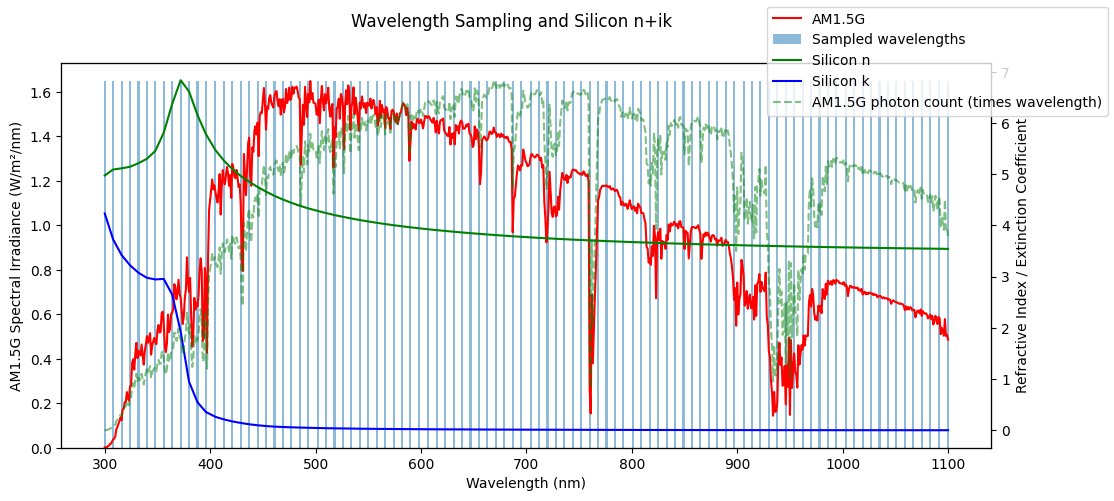

In [3]:
wavelength_plot = np.linspace(300,1100,1000).astype(int)
fig,ax = plt.subplots(figsize=(12,5))
ax.bar(wavelengths.cpu(),np.max(am15g[wavelength_plot]),label='Sampled wavelengths',width=2,alpha=0.5)
ax.plot(wavelength_plot,am15g[wavelength_plot],'r',label='AM1.5G')
ax2 = ax.twinx()
ax2.plot(wavelengths.cpu(),si.get_refractive_index(wavelengths.cpu().numpy()),'g',label='Silicon n')
ax2.plot(wavelengths.cpu(),si.get_extinction_coefficient(wavelengths.cpu().numpy()),'b',label='Silicon k')
ax3 = ax.twinx()
ax3.plot(wavelength_plot,am15g[wavelength_plot]*wavelength_plot,'g--',label='AM1.5G photon count (times wavelength)',alpha=0.5)
ax3.get_yaxis().set_visible(False)
fig.suptitle('Wavelength Sampling and Silicon n+ik')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('AM1.5G Spectral Irradiance (W/m²/nm)')
ax2.set_ylabel('Refractive Index / Extinction Coefficient')
fig.legend()

In [4]:
# Generate and perform simulation
params = torch.tensor([[20.,0.],[20,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
sim.solve_global_smatrix()

In [ ]:
#The true incident input power is not necessarily 0.5, depending on the polarization state and the incident angle and azimuthal angle.
#This is a bit weird, but is how rcwa works. The input polarization amplitude directly sets the E field amplitudes of the incoming waves, 
# IN FOURIER SPACE, and the actual power carried by these waves depends on the E->H transform (which depends on angle, wavelength, etc).

#polarization = [np.sqrt(2)/2.,np.sqrt(2)/2.]  # x and y components
#polarization = [0.,1.] # y-polarized
polarization = [1.,0.] # x-polarized

sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')
E_i = sim.E_i                       # shape (2*order_N,1), complex
Vi  = sim.Vi                         # E->H transform for input half-space

H_i = torch.matmul(Vi, E_i)          # H Fourier amplitudes for incoming waves

Ex = E_i[:sim.order_N,0]             # Ex per order
Ey = E_i[sim.order_N:,0]             # Ey per order
Hx = H_i[:sim.order_N,0]             # Hx per order
Hy = H_i[sim.order_N:,0]             # Hy per order

# time-averaged Poynting flux through z - summed over all fourier components (per unit cell)
Pz = 0.5 * torch.real(torch.sum(Ex * torch.conj(Hy) - Ey * torch.conj(Hx)))
x_samples = torcwa.rcwa_geo.x 
#P_inc = torch.trapz(Pz*torch.ones_like(x_samples), x_samples)
P_inc = Pz * torcwa.rcwa_geo.Lx  # line-integrated incident power density

# Calculate total R/T by summing efficiencies over all orders
R_total = 0.
T_total = 0.

# Iterate over all diffraction orders defined in the simulation
for ox in sim.order_x:
    for oy in sim.order_y:
        od = [ox.item(), oy.item()]
        
        # Sum co-polarized (xx) and cross-polarized (yx) components
        # Note: 'yx' denotes Output Y due to Input X
        
        # Reflection
        r_xx = sim.S_parameters(orders=od, direction='forward', port='reflection', polarization='xx', ref_order=[0,0])
        r_yx = sim.S_parameters(orders=od, direction='forward', port='reflection', polarization='yx', ref_order=[0,0])
        R_total += torch.abs(r_xx)**2 + torch.abs(r_yx)**2
        
        # Transmission
        t_xx = sim.S_parameters(orders=od, direction='forward', port='transmission', polarization='xx', ref_order=[0,0])
        t_yx = sim.S_parameters(orders=od, direction='forward', port='transmission', polarization='yx', ref_order=[0,0])
        T_total += torch.abs(t_xx)**2 + torch.abs(t_yx)**2


print('Incident power (per unit cell) =', Pz.item())
print('Expected power (per unit cell) =', 0.5 / np.cos(inc_ang) * (np.cos(azi_ang)**2 + np.sin(azi_ang)**2*np.cos(inc_ang)**2))
print(f'line-integrated incident power density = {P_inc.item():.4f}')
print(f'S-parameter reflectance = {R_total.item():.4f}')
print(f'S-parameter transmission = {T_total.item():.4f}')
print(f'Absorbed power total = {(1 - R_total - T_total).item():.4f}')

In [ ]:
# choose probe planes (just above / below film). use same device dtype as sim
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(-3*h,device=sim._device, dtype=geo_dtype) #sample far away from interface to ensure evanescent fields are gone

# request fields at both planes: x_axis is your x sampling (1D tensor), y0 is y coordinate (often 0)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(torcwa.rcwa_geo.x, torch.stack((z_top,z_bot,z_air)), y=0.0)

# Ex,Hy shapes: (nx, 2)  (nx across x, 2 planes)
S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,3)

# integrate over x to get power (per unit cell). Integrate using trapezoid rule.
x_line = torcwa.rcwa_geo.x
P_top = torch.trapezoid(S_z[:,0], x_line).item()
P_bot = torch.trapezoid(S_z[:,1], x_line).item()
P_air = torch.trapezoid(S_z[:,2], x_line).item()
P_absorbed_film = P_top - P_bot
P_absorbed_grating = P_air - P_top

print('Sanity check: power conservation and absorption by Poynting flux')
print(f'P_in  (top)   = {P_top:.4f}')
print(f'P_out (bottom)= {P_bot:.4f}')
print(f'P_absorbed (film) = {P_absorbed_film:.4f}')
print(f'P_absorbed (grating) = {P_absorbed_grating:.4f}')
print(f'P_air (z=0)   = {P_air:.4f}')
print(f'Absorptance by Poynting flux in film = {P_absorbed_film / P_inc:.4f}')
print(f'Absorptance by Poynting flux in grating = {P_absorbed_grating / P_inc:.4f}')
print(f'Total reflection by Poynting flux = {(P_inc-P_air) / P_inc:.4f}')
print(f'Total transmission by Poynting flux = {P_bot / P_inc:.4f}')
print(f'Total absorptance by Poynting flux = {(P_absorbed_film + P_absorbed_grating) / P_inc:.4f}')

In [ ]:
# sampling (increase for better convergence)
n_samples = 500
torcwa.rcwa_geo.nx = n_samples
torcwa.rcwa_geo.grid()
x_vol = torcwa.rcwa_geo.x
nz_film = n_samples
nz_grat = n_samples
sine_sample = get_sine_eps(x_vol,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])

z_film = torch.linspace(A, A + h, nz_film, device=device, dtype=geo_dtype)   # film region
z_grat = torch.linspace(0.0, A, nz_grat, device=device, dtype=geo_dtype)     # grating region

# get fields
[Ex_f, Ey_f, Ez_f], _ = sim.field_xz(x_vol, z_film, torch.tensor(0., device=device, dtype=geo_dtype))
[Ex_g, Ey_g, Ez_g], _ = sim.field_xz(x_vol, z_grat, torch.tensor(0., device=device, dtype=geo_dtype))

# squared field magnitude
En2_f = torch.abs(Ex_f)**2 + torch.abs(Ey_f)**2 + torch.abs(Ez_f)**2   # (nx, nz_film)
En2_g = torch.abs(Ex_g)**2 + torch.abs(Ey_g)**2 + torch.abs(Ez_g)**2   # (nx, nz_grat)

# angular freq (LH units: c=1 so freq = 1/λ; wavelength variable is in nm)
omega = 2.0 * torch.pi / wavelength.to(device=device, dtype=geo_dtype)   # tensor scalar

# film permittivity (complex) and imaginary part
eps_film = si_eps[n_wavelength].to(device=device, dtype=torch.complex64)
eps_im_f = torch.imag(eps_film)   # scalar

# grating permittivity (x-dependent)
eps_grat = sine_sample.squeeze(1).to(device=device, dtype=torch.complex64)   # (nx,)
eps_im_g = torch.imag(eps_grat).unsqueeze(1)   # (nx,1) , will broadcast over z

# local power density: 0.5 * omega * Im(eps) * |E|^2  (Heaviside-Lorentz units)
pdens_f = 0.5 * omega * eps_im_f * En2_f    # (nx, nz_film)
pdens_g = 0.5 * omega * eps_im_g * En2_g    # (nx, nz_grat)

# integrate over x then z (per unit cell)
Px_f = torch.trapz(pdens_f, x=x_vol, dim=0)        # (nz_film,)
Pvol_f = torch.trapz(Px_f, x=z_film, dim=0)        # scalar

Px_g = torch.trapz(pdens_g, x=x_vol, dim=0)        # (nz_grat,)
Pvol_g = torch.trapz(Px_g, x=z_grat, dim=0)        # scalar

# bring to CPU scalars for comparison
Pvol_f_val = Pvol_f.cpu().item()
Pvol_g_val = Pvol_g.cpu().item()

# Poynting computed earlier: P_absorbed_film, P_absorbed_grating (from previous cell)
print(f"Poynting film (P_top - P_bot)       = {P_absorbed_film:.6e}")
print(f"Volume integral film                  = {Pvol_f_val:.6e}")
print(f"Relative error (film)                 = {(Pvol_f_val - P_absorbed_film)/P_absorbed_film:.3e}")

print(f"Poynting grating (P_air - P_top)     = {P_absorbed_grating:.6e}")
print(f"Volume integral grating               = {Pvol_g_val:.6e}")
print(f"Relative error (grating)              = {(Pvol_g_val - P_absorbed_grating)/P_absorbed_grating:.3e}")

In [ ]:
#Do a bunch of convergence checks by varying first n_samples in poynting vector integration
P_absorbed_film_list0 = []
order_N = 40
nx_list = np.logspace(2,6,30,dtype=int)
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order = [order_N,0]
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(-3*h,device=sim._device, dtype=geo_dtype)         # (nx,)
for nx_test in tqdm(nx_list):
    torcwa.rcwa_geo.nx = 100
    torcwa.rcwa_geo.grid()

    sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
    sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=A,eps=sine_eps)
    sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')
    #torcwa.rcwa_geo.nx = nx_test
    #torcwa.rcwa_geo.grid()
    sample_x = torcwa.rcwa_geo
    sample_x.nx = nx_test
    sample_x.grid()
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(sample_x.x, torch.stack((z_top,z_bot,z_air)), y=0.0)

    # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    x_line = sample_x.x
    P_top = torch.trapezoid(S_z[:,0], x_line).item()
    P_bot = torch.trapezoid(S_z[:,1], x_line).item()
    P_absorbed_film = P_top - P_bot
    P_absorbed_film_list0.append(P_absorbed_film)

plt.plot(nx_list, P_absorbed_film_list0, marker='o')
plt.xlabel('Number of samples n_samples')
plt.ylabel('Absorbed Power in Film')
plt.yscale('log')
plt.xscale('log')
#plt.vlines(x=5000,ymin=1.712*10, ymax=1.718*10, color='r', linestyle='--', label='nx=5000')
#plt.ylim(1.712*10, 1.718*10)
#plt.xlim(60,2e6)
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs n_samples \nUsed fourier order N={order_N}, used n_grating samples=100')
plt.legend()
plt.show()

In [ ]:
P_absorbed_film_list0[-1]

In [ ]:
#Do a bunch of convergence checks then varying n_grating in poynting vector integration
P_absorbed_film_list1 = []
order_N = 40
nsample_list = np.logspace(2,6,30,dtype=int)
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order = [order_N,0]
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(-3*h,device=sim._device, dtype=geo_dtype)
for nsample_test in tqdm(nsample_list):
    torcwa.rcwa_geo.nx = nsample_test
    torcwa.rcwa_geo.grid()

    sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
    sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=A,eps=sine_eps)
    sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')

    sample_x = torcwa.rcwa_geo
    sample_x.nx = 5000
    sample_x.grid()
    x_samples = sample_x.x
    
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_samples, torch.stack((z_top,z_bot,z_air)), y=0.0)

    # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    x_line = sample_x.x
    P_top = torch.trapezoid(S_z[:,0], x_line).item()
    P_bot = torch.trapezoid(S_z[:,1], x_line).item()
    P_absorbed_film = P_top - P_bot
    P_absorbed_film_list1.append(P_absorbed_film)

plt.plot(nsample_list, P_absorbed_film_list1, marker='o')
plt.xlabel('Number of grating samples (n_grating)')
plt.ylabel('Absorbed Power in Film')
plt.yscale('log')
plt.xscale('log')
#plt.vlines(x=100,ymin=1.71757*10, ymax=1.71773*10, color='r', linestyle='--', label='n_grating=100')
#plt.ylim(1.71757*10, 1.71773*10)
#plt.xlim(60,2e6)
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs n_grating \nUsed fourier order N={order_N}, used n_samples = {sample_x.nx}')
plt.legend()
plt.show()

In [ ]:
P_absorbed_film_list1[-1]

In [ ]:
P_absorbed_film_list2 = []
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
Order_N_list = np.arange(25,200,5)
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
z_top = torch.clone(A)  # e.g. top of film
z_bot = torch.clone(A+h)  # e.g. bottom of film
z_air = torch.tensor(-3*h,device=sim._device, dtype=geo_dtype)

for order_N in tqdm(Order_N_list):
    torcwa.rcwa_geo.nx = 100
    torcwa.rcwa_geo.grid()
    order = [order_N,0]
    sine_eps = get_sine_eps(x_samples,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
    sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
    sim.add_input_layer()
    sim.add_output_layer()
    sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
    sim.add_layer(thickness=A,eps=sine_eps)
    sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
    sim.solve_global_smatrix()
    sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')

    sample_x = torcwa.rcwa_geo
    sample_x.nx = 5000
    sample_x.grid()
    x_samples = sample_x.x
    [Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_samples, torch.stack((z_top,z_bot,z_air)), y=0.0)

    # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    x_line = sample_x.x
    P_top = torch.trapezoid(S_z[:,0], x_line).item()
    P_bot = torch.trapezoid(S_z[:,1], x_line).item()
    P_absorbed_film = P_top - P_bot
    P_absorbed_film_list2.append(P_absorbed_film)

plt.plot(Order_N_list, P_absorbed_film_list2, marker='o')
plt.xlabel('Fourier Order N')
plt.ylabel('Absorbed Power in Film')
plt.yscale('log')
#plt.vlines(x=40,ymin=1.713e1,ymax=1.718e1, color='r', linestyle='--', label='N=40')
#plt.ylim(1.713e1,1.718e1)
plt.legend()
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs fourier order N \nUsed n_samples = {sample_x.nx}, Used n_grating = {100}')

In [ ]:
P_absorbed_film_list2[-1]

In [ ]:
# sampling (increase for better convergence)
n_samples_list = [500, 1000, 2000, 3000]#, 4000, 5000, 7000]
P_absorbed_film_list3 = []
Poynting_list = []


torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
params = torch.tensor([[20.,0.],[20.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
sim.solve_global_smatrix()
sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')


for n_samples in tqdm(n_samples_list):
    torcwa.rcwa_geo.nx = n_samples
    torcwa.rcwa_geo.grid()
    x_vol = torcwa.rcwa_geo.x
    nz_film = n_samples
    sine_sample = get_sine_eps(x_vol,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])

    z_film = torch.linspace(A, A + h, nz_film, device=device, dtype=geo_dtype)   # film region


    # get fields
    [Ex, Ey, Ez], _ = sim.field_xz(x_vol, z_film, torch.tensor(0., device=device, dtype=geo_dtype))
    [Ex_p,Ey_p,Ez_p], [Hx, Hy, Hz] = sim.field_xz(x_vol, torch.stack((z_top,z_bot)), torch.tensor(0., device=device, dtype=geo_dtype))


    # squared field magnitude
    En2 = torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2   # (nx, nz_film)

    # angular freq (LH units: c=1 so freq = 1/λ; wavelength variable is in nm)
    omega = 2.0 * torch.pi / wavelength.to(device=device, dtype=geo_dtype)   # tensor scalar

    # film permittivity (complex) and imaginary part
    eps_film = si_eps[n_wavelength].to(device=device, dtype=torch.complex64)
    eps_im = torch.imag(eps_film)   # scalar

    # local power density: 0.5 * omega * Im(eps) * |E|^2  (Heaviside-Lorentz units)
    pdens = 0.5 * omega * eps_im * En2    # (nx, nz_film)
    # integrate over x then z (per unit cell)
    Px = torch.trapz(pdens, x=x_vol, dim=0)        # (nz_film,)
    Pvol = torch.trapz(Px, x=z_film, dim=0)        # scalar

    # bring to CPU scalars for comparison
    Pvol_val = Pvol.cpu().item()
    P_absorbed_film_list3.append(Pvol_val)

        # Compute Poynting vector
    S_z = 0.5 * torch.real(Ex_p * torch.conj(Hy) - Ey_p * torch.conj(Hx))   # shape (nx,2)

    # integrate over x to get power (per unit cell). Integrate using trapezoid rule.
    P_top = torch.trapezoid(S_z[:,0], x_vol).item()
    P_bot = torch.trapezoid(S_z[:,1], x_vol).item()
    P_absorbed_film = P_top - P_bot
    Poynting_list.append(P_absorbed_film)




In [ ]:
plt.plot(n_samples_list, P_absorbed_film_list3, marker='o', label='Volume Integral')
plt.plot(n_samples_list, Poynting_list, marker='x', label='Poynting Vector')
plt.xlabel('Number of x/z samples in film for absorbed power density integration')
plt.ylabel('Absorbed Power in film')
plt.title(f'Convergence of Absorbed Power using Poynting Vector in Film vs fourier order N \nUsed n_samples = {torcwa.rcwa_geo.nx}, Used N = {order_N}')
plt.hlines(y=P_absorbed_film_list0[-1], xmin=n_samples_list[0], xmax=n_samples_list[-1], color='r', linestyle='--', label='Best Approximation from Poynting')
plt.legend()
plt.show()

In [ ]:
P_absorbed_film_list3

In [ ]:
Loaded = torch.load("../Data/Modulated_Silicon_Data_5000_structures.pt")
polarization = [1/np.sqrt(2), 1/np.sqrt(2)]  # x and y components
params = Loaded['features'].to(device)  # shape (1000, 6)

In [ ]:
params = Loaded['features'][torch.argmax(Loaded['targets'][:,1])].to(device)  # shape (6,)
n_wavelength = 25
wavelength = wavelengths[n_wavelength] 
print(wavelength)

In [ ]:
# Define simulation again
torcwa.rcwa_geo.nx = 5000
torcwa.rcwa_geo.grid()
#params = torch.tensor([[20.,0.],[40.,np.pi],[20.,0.]],dtype=geo_dtype,device=device)  # amplitude (nm), phase (rad)
wavelength = wavelengths[n_wavelength]   # nm
A = torch.sum(params[:,0])
order_N = 40
order = [order_N,0]
inc_ang = 0.*(np.pi/180)    # radian
azi_ang = 0.*(np.pi/180)    # radian
sine_eps = get_sine_eps(torcwa.rcwa_geo.x,params=params,grating_period=grating_period,eps=si_eps[n_wavelength])
sim = torcwa.rcwa(freq=1/wavelength,order=order,L=L,dtype=sim_dtype,device=device)
sim.add_input_layer()
sim.add_output_layer()
sim.set_incident_angle(inc_ang=inc_ang,azi_ang=azi_ang)
sim.add_layer(thickness=A,eps=sine_eps)
sim.add_layer(thickness=h,eps=si_eps[n_wavelength])
sim.solve_global_smatrix()
sim.source_planewave(amplitude=polarization,direction='forward',notation='xy')

# View XZ-plane fields
x_plot = torch.linspace(0, L[0], 500, device=device)
z_plot = torch.linspace(-h, 1.5*h, 1000, device=device)
[Ex, Ey, Ez], [Hx, Hy, Hz] = sim.field_xz(x_plot,z_plot,torch.tensor(0))
Enorm = torch.sqrt(torch.abs(Ex)**2 + torch.abs(Ey)**2 + torch.abs(Ez)**2)
Hnorm = torch.sqrt(torch.abs(Hx)**2 + torch.abs(Hy)**2 + torch.abs(Hz)**2)
Sx = 0.5 * torch.real(Ey * torch.conj(Hz) - Ez * torch.conj(Hy))
Sy = 0.5 * torch.real(Ez * torch.conj(Hx) - Ex * torch.conj(Hz))
Sz = 0.5 * torch.real(Ex * torch.conj(Hy) - Ey * torch.conj(Hx))
Snorm = torch.sqrt(Sx**2 + Sy**2 + Sz**2)
x_plot = x_plot.cpu()
z_plot = z_plot.cpu()

In [ ]:
fig, axes = plt.subplots(figsize=(15,12),nrows=3,ncols=4)

# compute per-row vmin/vmax so each row shares a common color scale
row0_imgs = [Enorm, torch.abs(Ex), torch.abs(Ey), torch.abs(Ez)]
row1_imgs = [Hnorm, torch.abs(Hx), torch.abs(Hy), torch.abs(Hz)]
row2_imgs = [Snorm, Sx.abs(), Sy.abs(), Sz.abs()]

row0_vmin = min([x.min().item() for x in row0_imgs])
row0_vmax = max([x.max().item() for x in row0_imgs])
row1_vmin = min([x.min().item() for x in row1_imgs])
row1_vmax = max([x.max().item() for x in row1_imgs])
row2_vmin = min([x.min().item() for x in row2_imgs])
row2_vmax = max([x.max().item() for x in row2_imgs])

im0 = axes[0,0].imshow(torch.transpose(Enorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,0].set(title='E norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im1 = axes[0,1].imshow(torch.transpose(torch.abs(Ex),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,1].set(title='Ex abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im2 = axes[0,2].imshow(torch.transpose(torch.abs(Ey),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,2].set(title='Ey abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im3 = axes[0,3].imshow(torch.transpose(torch.abs(Ez),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row0_vmin, vmax=row0_vmax)
axes[0,3].set(title='Ez abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im4 = axes[1,0].imshow(torch.transpose(Hnorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,0].set(title='H norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im5 = axes[1,1].imshow(torch.transpose(torch.abs(Hx),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,1].set(title='Hx abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im6 = axes[1,2].imshow(torch.transpose(torch.abs(Hy),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,2].set(title='Hy abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im7 = axes[1,3].imshow(torch.transpose(torch.abs(Hz),-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row1_vmin, vmax=row1_vmax)
axes[1,3].set(title='Hz abs', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im8 = axes[2,0].imshow(torch.transpose(Snorm,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row2_vmin, vmax=row2_vmax)
axes[2,0].set(title='S norm', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im9 = axes[2,1].imshow(torch.transpose(Sx,-2,-1).cpu(), cmap='jet', origin='lower',
                       extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                       vmin=row2_vmin, vmax=row2_vmax)
axes[2,1].set(title='Sx', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im10 = axes[2,2].imshow(torch.transpose(Sy,-2,-1).cpu(), cmap='jet', origin='lower',
                        extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                        vmin=row2_vmin, vmax=row2_vmax)
axes[2,2].set(title='Sy', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

im11 = axes[2,3].imshow(torch.transpose(Sz,-2,-1).cpu(), cmap='jet', origin='lower',
                        extent=[x_plot[0],x_plot[-1],z_plot[0],z_plot[-1]],
                        vmin=row2_vmin, vmax=row2_vmax)
axes[2,3].set(title='Sz', xlim=(0,L[0]), xlabel='x (nm)', ylim=(z_plot[0],z_plot[-1]), ylabel='z (nm)')

# adjust layout to leave room on the right for three colorbars
fig.subplots_adjust(right=0.92, hspace=0.35, wspace=0.3)

# one colorbar per row (uses the representative mappable but all images share vmin/vmax)
cbar0 = fig.colorbar(im0, ax=axes[0, :], location='right', shrink=0.9, pad=0.02)
cbar0.set_label('E (A.U.)')
cbar1 = fig.colorbar(im4, ax=axes[1, :], location='right', shrink=0.9, pad=0.02)
cbar1.set_label('H (A.U.)')
cbar2 = fig.colorbar(im8, ax=axes[2, :], location='right', shrink=0.9, pad=0.02)
cbar2.set_label('S (A.U.)')

fig.suptitle(f'xz-plane field distribution at $\lambda$ = {wavelength} nm and y = 0 nm \n polarization = $E_x$ = {polarization[0]:.3f}, $E_y$ = {polarization[1]:.3f} \n incident angle = {inc_ang*180/np.pi:.1f}°, azimuthal angle = {azi_ang*180/np.pi:.1f}°', fontsize=16)
plt.show()

In [ ]:
plt.plot(x_axis,sine_eps.real.cpu(),label='Sine grating eps real')
plt.plot(x_axis,sine_eps.imag.cpu(),label='Sine grating eps imag')
plt.legend()

In [ ]:
# verify linearity of fields vs nonlinearity of norms
x_plot = torch.linspace(0, L[0], 300, device=device)
z_plot = torch.linspace(-h, 1.5*h, 300, device=device)
# get fields for x and y polarizations
sim.source_planewave(amplitude=[1.,0.], direction='forward', notation='xy')
[Ex_x, Ey_x, Ez_x], [Hx_x, Hy_x, Hz_x] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

sim.source_planewave(amplitude=[0.,1.], direction='forward', notation='xy')
[Ex_y, Ey_y, Ez_y], [Hx_y, Hy_y, Hz_y] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

# direct diagonal
a = 1/np.sqrt(2)
sim.source_planewave(amplitude=[a,a], direction='forward', notation='xy')
[Ex_d, Ey_d, Ez_d], [Hx_d, Hy_d, Hz_d] = sim.field_xz(x_plot, z_plot, torch.tensor(0))

# check linear superposition of complex fields
Ex_sum = a*Ex_x + a*Ex_y
Ey_sum = a*Ey_x + a*Ey_y
Ez_sum = a*Ez_x + a*Ez_y

print('max abs error Ex:', torch.max(torch.abs(Ex_sum - Ex_d)).item())
print('max abs error Ey:', torch.max(torch.abs(Ey_sum - Ey_d)).item())
print('max abs error Ez:', torch.max(torch.abs(Ez_sum - Ez_d)).item())

# check norms (not linear)
Enorm_sum = 0.5*(torch.sqrt(torch.abs(Ex_x)**2 + torch.abs(Ey_x)**2 + torch.abs(Ez_x)**2) +
                 torch.sqrt(torch.abs(Ex_y)**2 + torch.abs(Ey_y)**2 + torch.abs(Ez_y)**2))
Enorm_diag = torch.sqrt(torch.abs(Ex_d)**2 + torch.abs(Ey_d)**2 + torch.abs(Ez_d)**2)
print('Note that the norms are not linearly additive:')
print(f'mean(Enorm_sum - Enorm_diag) = {torch.mean(Enorm_sum - Enorm_diag).item():.6e}')